<a href="https://colab.research.google.com/github/BenCoop16/IS-477/blob/main/IS477_Proj_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [158]:
!pip install vaderSentiment


In [159]:
import requests
import pandas as pd
import datetime
import time
import yfinance as yf
import time
from google.colab import files
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [160]:
all_posts = []
batch_after = "2024-01-01"
batch_before = "2026-01-01"

for i in range(20):
    params = {"subreddit": "Bitcoin", "after": batch_after, "before": batch_before, "limit": 100, "sort": "asc"}
    response = requests.get(url="https://arctic-shift.photon-reddit.com/api/posts/search", params=params)
    posts = response.json()
    batch = posts['data']
    if not batch:
        print(f"No more data at batch {i}")
        break
    all_posts.extend(batch)
    batch_after = batch[-1]['created_utc']
    print(f"Batch {i+1}: {len(batch)} posts, total so far: {len(all_posts)}")
    time.sleep(1)

df_bitcoin = pd.DataFrame(all_posts)[['id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit']]
df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['created_utc'], unit='s')
print(df_bitcoin.shape)

Batch 1: 100 posts, total so far: 100
Batch 2: 100 posts, total so far: 200
Batch 3: 100 posts, total so far: 300
Batch 4: 100 posts, total so far: 400
Batch 5: 100 posts, total so far: 500
Batch 6: 100 posts, total so far: 600
Batch 7: 100 posts, total so far: 700
Batch 8: 100 posts, total so far: 800
Batch 9: 100 posts, total so far: 900
Batch 10: 100 posts, total so far: 1000
Batch 11: 100 posts, total so far: 1100
Batch 12: 100 posts, total so far: 1200
Batch 13: 100 posts, total so far: 1300
Batch 14: 100 posts, total so far: 1400
Batch 15: 100 posts, total so far: 1500
Batch 16: 100 posts, total so far: 1600
Batch 17: 100 posts, total so far: 1700
Batch 18: 100 posts, total so far: 1800
Batch 19: 100 posts, total so far: 1900
Batch 20: 100 posts, total so far: 2000
(2000, 9)


In [161]:
df_bitcoin = df_bitcoin[['id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit']]
df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['created_utc'], unit='s')
df_bitcoin.to_csv('reddit_bitcoin_raw.csv', index=False)

In [162]:
df_bitcoin

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp
0,18vkhs0,Crypto Trading at Bybit! Sign up,[removed],1,1.00,0,1704067279,Bitcoin,2024-01-01 00:01:19
1,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.00,1,1704067351,Bitcoin,2024-01-01 00:02:31
2,18vkl5i,Crypto Trading at Bybit! Sign up at,[removed],1,1.00,1,1704067574,Bitcoin,2024-01-01 00:06:14
3,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.00,2,1704067808,Bitcoin,2024-01-01 00:10:08
4,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.00,7,1704068581,Bitcoin,2024-01-01 00:23:01
...,...,...,...,...,...,...,...,...,...
1995,191fk7v,Bitcoin is headed to the moon as we speak,[removed],1,1.00,0,1704698883,Bitcoin,2024-01-08 07:28:03
1996,191fpi7,Buy High,"Well boys and girls, I hope everyone is watchi...",1,0.50,11,1704699482,Bitcoin,2024-01-08 07:38:02
1997,191fw7s,"$BTC is having a bit of a rough patch, and Asi...",,1,0.30,5,1704700195,Bitcoin,2024-01-08 07:49:55
1998,191fxdi,Gem i found on r/wallstreetbets,,12,1.00,2,1704700319,Bitcoin,2024-01-08 07:51:59


In [163]:
df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01")
df_price.to_csv('crypto_prices_raw.csv')

/tmp/ipykernel_9651/4184534066.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [164]:
df_price.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


In [165]:
###Data files acquired/created and uploaded to GitHub

In [166]:
print(df_bitcoin.shape)
print(df_price.shape)
print(df_bitcoin.head())
print(df_price.head())

(2000, 9)
(731, 5)
        id                                              title  \
0  18vkhs0                   Crypto Trading at Bybit! Sign up   
1  18vkiob  Anyone using AI legitimately to trade better? ...   
2  18vkl5i                Crypto Trading at Bybit! Sign up at   
3  18vkngq                       ETF approval, demand change?   
4  18vkvy4  Mass Adoption after Mass Awareness - We are ge...   

                                            selftext  score  upvote_ratio  \
0                                          [removed]      1           1.0   
1  Is anyone actually using AI to improve their c...      1           1.0   
2                                          [removed]      1           1.0   
3  Has anyone looked at what the lagtime is betwe...      1           1.0   
4  Visiting Flagstaff for New Years and found my ...      1           1.0   

   num_comments  created_utc subreddit           timestamp  
0             0   1704067279   Bitcoin 2024-01-01 00:01:19  
1    

In [167]:
print("Duplicates:", df_bitcoin.duplicated(subset='id').sum())
print("\nMissing values:")
print(df_bitcoin.isnull().sum())
print("\nRemoved posts (selftext is [removed]):", (df_bitcoin['selftext'] == '[removed]').sum())
print("Deleted posts (selftext is [deleted]):", (df_bitcoin['selftext'] == '[deleted]').sum())

Duplicates: 0

Missing values:
id              0
title           0
selftext        0
score           0
upvote_ratio    0
num_comments    0
created_utc     0
subreddit       0
timestamp       0
dtype: int64

Removed posts (selftext is [removed]): 364
Deleted posts (selftext is [deleted]): 10


In [168]:
df_bitcoin_clean = df_bitcoin[df_bitcoin['selftext'] != '[removed]']
df_bitcoin_clean = df_bitcoin_clean[df_bitcoin_clean['selftext'] != '[deleted]']
df_bitcoin_clean = df_bitcoin_clean.reset_index(drop=True)
print(df_bitcoin_clean.shape)

(1626, 9)


In [169]:
print("Duplicates:", df_price.duplicated().sum())
print("\nMissing values:")
print(df_price.isnull().sum())
print("\nPrice data types:")
print(df_price.dtypes)

Duplicates: 0

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Price data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object


In [170]:
df_price_clean = df_price.copy()
df_price_clean.columns = ['close', 'high', 'low', 'open', 'volume']
df_price_clean = df_price_clean.reset_index()
df_price_clean.columns = ['date', 'close', 'high', 'low', 'open', 'volume']
df_price_clean['date'] = pd.to_datetime(df_price_clean['date'])
print(df_price_clean.head())
print(df_price_clean.dtypes)

        date         close          high           low          open  \
0 2024-01-01  44167.332031  44175.437500  42214.976562  42280.234375   
1 2024-01-02  44957.968750  45899.707031  44176.949219  44187.140625   
2 2024-01-03  42848.175781  45503.242188  40813.535156  44961.601562   
3 2024-01-04  44179.921875  44770.023438  42675.175781  42855.816406   
4 2024-01-05  44162.691406  44353.285156  42784.718750  44192.980469   

        volume  
0  18426978443  
1  39335274536  
2  46342323118  
3  30448091210  
4  32336029347  
date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume             int64
dtype: object


In [171]:
df_bitcoin_clean['date'] = df_bitcoin_clean['timestamp'].dt.normalize()
df_daily_reddit = df_bitcoin_clean.groupby('date').agg(
    post_count=('id', 'count'),
    avg_score=('score', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    avg_comments=('num_comments', 'mean')
).reset_index()
print(df_daily_reddit.shape)
print(df_daily_reddit.head())

(8, 5)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments
0 2024-01-01         144   2.701389          0.960000     21.965278
1 2024-01-02         310   2.093548          0.980903     21.074194
2 2024-01-03         275   1.138182          0.984982     14.443636
3 2024-01-04         216   2.699074          0.985417     17.185185
4 2024-01-05         204   1.186275          0.990539     23.612745


In [172]:
print("Reddit date range:")
print(df_bitcoin_clean['timestamp'].min())
print(df_bitcoin_clean['timestamp'].max())

Reddit date range:
2024-01-01 00:02:31
2024-01-08 08:23:30


In [173]:
df_price_monthly = df_price_clean.copy()
df_price_monthly['date'] = df_price_monthly['date'].dt.to_period('M').dt.to_timestamp()
df_price_monthly = df_price_monthly.groupby('date').agg(
    avg_close=('close', 'mean'),
    avg_volume=('volume', 'mean'),
    price_change=('close', lambda x: x.iloc[-1] - x.iloc[0])
).reset_index()
df_merged = pd.merge(df_daily_reddit, df_price_monthly, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(1, 8)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01         144   2.701389              0.96     21.965278   

      avg_close    avg_volume  price_change  
0  42919.612399  2.664255e+10  -1584.726562  


In [174]:
df_bitcoin_clean.to_csv('reddit_bitcoin_clean.csv', index=False)
df_price_clean.to_csv('crypto_prices_clean.csv', index=False)
df_merged.to_csv('merged_data.csv', index=False)
print("All files saved!")

All files saved!


In [175]:
analyzer = SentimentIntensityAnalyzer()
df_bitcoin_clean['sentiment'] = df_bitcoin_clean['title'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
print(df_bitcoin_clean[['title', 'sentiment']].head(10))

                                               title  sentiment
0  Anyone using AI legitimately to trade better? ...     0.4404
1                       ETF approval, demand change?     0.3818
2  Mass Adoption after Mass Awareness - We are ge...     0.0000
3                                Bitcoin Yearly Lows    -0.2023
4                       Happy new year motherfuckers     0.5719
5  On the Lightning Network does the node operato...     0.3400
6                              This is where it ends     0.0000
7  Best place to store your Bitcoin from Coinbase...     0.8442
8  Yo why the Bitcoin fees so high right now is t...     0.0000
9                             Happy new year to all!     0.6114


In [176]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_bitcoin_clean['sentiment_label'] = df_bitcoin_clean['sentiment'].apply(label_sentiment)
print(df_bitcoin_clean['sentiment_label'].value_counts())

sentiment_label
neutral     873
positive    508
negative    245
Name: count, dtype: int64


In [177]:
df_daily_reddit = df_bitcoin_clean.groupby('date').agg(
    post_count=('id', 'count'),
    avg_score=('score', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    avg_comments=('num_comments', 'mean'),
    avg_sentiment=('sentiment', 'mean'),
    positive_ratio=('sentiment_label', lambda x: (x == 'positive').sum() / len(x)),
    negative_ratio=('sentiment_label', lambda x: (x == 'negative').sum() / len(x))
).reset_index()

print(df_daily_reddit.shape)
print(df_daily_reddit.head())

(8, 8)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01         144   2.701389          0.960000     21.965278   
1 2024-01-02         310   2.093548          0.980903     21.074194   
2 2024-01-03         275   1.138182          0.984982     14.443636   
3 2024-01-04         216   2.699074          0.985417     17.185185   
4 2024-01-05         204   1.186275          0.990539     23.612745   

   avg_sentiment  positive_ratio  negative_ratio  
0       0.080592        0.305556        0.187500  
1       0.094937        0.296774        0.129032  
2       0.041343        0.305455        0.229091  
3       0.060009        0.277778        0.143519  
4       0.135426        0.362745        0.102941  


In [178]:
df_price_clean['price_change'] = df_price_clean['close'].diff()
df_price_clean['price_pct_change'] = df_price_clean['close'].pct_change() * 100

df_merged = pd.merge(df_daily_reddit, df_price_clean, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(8, 15)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01         144   2.701389          0.960000     21.965278   
1 2024-01-02         310   2.093548          0.980903     21.074194   
2 2024-01-03         275   1.138182          0.984982     14.443636   
3 2024-01-04         216   2.699074          0.985417     17.185185   
4 2024-01-05         204   1.186275          0.990539     23.612745   

   avg_sentiment  positive_ratio  negative_ratio         close          high  \
0       0.080592        0.305556        0.187500  44167.332031  44175.437500   
1       0.094937        0.296774        0.129032  44957.968750  45899.707031   
2       0.041343        0.305455        0.229091  42848.175781  45503.242188   
3       0.060009        0.277778        0.143519  44179.921875  44770.023438   
4       0.135426        0.362745        0.102941  44162.691406  44353.285156   

            low          open       volume  price_change  price_pct_change  
0  4221

In [179]:
from scipy import stats

sentiment_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count', 'avg_score']
price_cols = ['close', 'price_change', 'price_pct_change', 'volume']

print('=== Pearson Correlation ===')
for sc in sentiment_cols:
    for pc in price_cols:
        subset = df_merged[[sc, pc]].dropna()
        r, p = stats.pearsonr(subset[sc], subset[pc])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {sc:25s} vs {pc:20s}: r={r:+.4f}, p={p:.4f} {sig}')

=== Pearson Correlation ===
  avg_sentiment             vs close               : r=+0.3383, p=0.4125 
  avg_sentiment             vs price_change        : r=+0.2665, p=0.5635 
  avg_sentiment             vs price_pct_change    : r=+0.2570, p=0.5780 
  avg_sentiment             vs volume              : r=-0.3184, p=0.4422 
  positive_ratio            vs close               : r=-0.4448, p=0.2695 
  positive_ratio            vs price_change        : r=-0.5062, p=0.2464 
  positive_ratio            vs price_pct_change    : r=-0.5127, p=0.2393 
  positive_ratio            vs volume              : r=-0.4227, p=0.2968 
  negative_ratio            vs close               : r=-0.6172, p=0.1030 
  negative_ratio            vs price_change        : r=-0.7013, p=0.0791 
  negative_ratio            vs price_pct_change    : r=-0.6945, p=0.0834 
  negative_ratio            vs volume              : r=+0.1375, p=0.7455 
  post_count                vs close               : r=-0.6243, p=0.0981 
  post_cou

In [180]:
print('=== Lag Correlation: avg_sentiment vs. future price_pct_change ===')
lag_results = []
for lag in range(0, min(8, len(df_merged) - 1)):
    df_lag = df_merged[['avg_sentiment', 'price_pct_change']].copy()
    df_lag['future_price_change'] = df_lag['price_pct_change'].shift(-lag)
    subset = df_lag.dropna()
    if len(subset) < 2:
        print(f'  Lag {lag} days: not enough data')
        continue
    r, p = stats.pearsonr(subset['avg_sentiment'], subset['future_price_change'])
    lag_results.append({'lag_days': lag, 'pearson_r': r, 'p_value': p})
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  Lag {lag} days: r={r:+.4f}, p={p:.4f} {sig}')

df_lag_results = pd.DataFrame(lag_results)

=== Lag Correlation: avg_sentiment vs. future price_pct_change ===
  Lag 0 days: r=+0.2570, p=0.5780 
  Lag 1 days: r=-0.3265, p=0.5276 
  Lag 2 days: r=+0.4260, p=0.4745 
  Lag 3 days: r=+0.8637, p=0.1363 
  Lag 4 days: r=-0.2068, p=0.8674 
  Lag 5 days: r=-1.0000, p=1.0000 
  Lag 6 days: not enough data


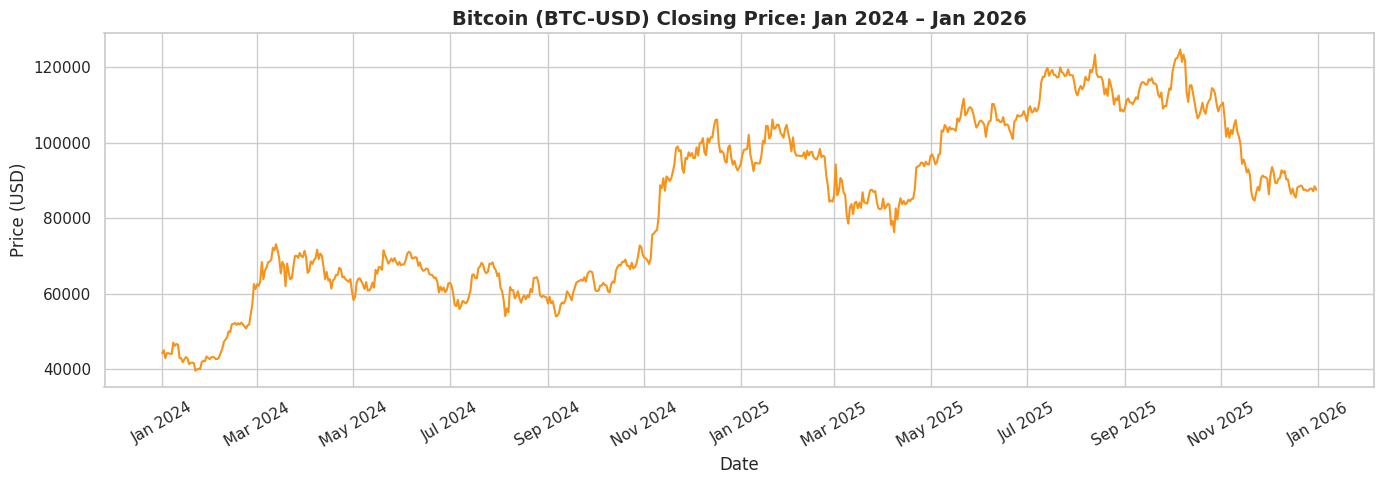

In [181]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5)
ax.set_title('Bitcoin (BTC-USD) Closing Price: Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_btc_price.png', dpi=150)
plt.show()

In [199]:
df_bitcoin_clean

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp,date,sentiment,sentiment_label
0,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.00,1,1704067351,Bitcoin,2024-01-01 00:02:31,2024-01-01,0.4404,positive
1,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.00,2,1704067808,Bitcoin,2024-01-01 00:10:08,2024-01-01,0.3818,positive
2,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.00,7,1704068581,Bitcoin,2024-01-01 00:23:01,2024-01-01,0.0000,neutral
3,18vkxzr,Bitcoin Yearly Lows,2012 - $4\n\n2013 - $65\n\n2014 - $200\n\n2015...,1,1.00,138,1704068769,Bitcoin,2024-01-01 00:26:09,2024-01-01,-0.2023,negative
4,18vkyzb,Happy new year motherfuckers,2023 was a good year. It was also a shitty yea...,1,1.00,4,1704068862,Bitcoin,2024-01-01 00:27:42,2024-01-01,0.5719,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
1621,191fe3n,When BTC hits $88K..,,5,1.00,1,1704698208,Bitcoin,2024-01-08 07:16:48,2024-01-08,0.0000,neutral
1622,191fpi7,Buy High,"Well boys and girls, I hope everyone is watchi...",1,0.50,11,1704699482,Bitcoin,2024-01-08 07:38:02,2024-01-08,0.0000,neutral
1623,191fw7s,"$BTC is having a bit of a rough patch, and Asi...",,1,0.30,5,1704700195,Bitcoin,2024-01-08 07:49:55,2024-01-08,0.0000,neutral
1624,191fxdi,Gem i found on r/wallstreetbets,,12,1.00,2,1704700319,Bitcoin,2024-01-08 07:51:59,2024-01-08,0.0000,neutral


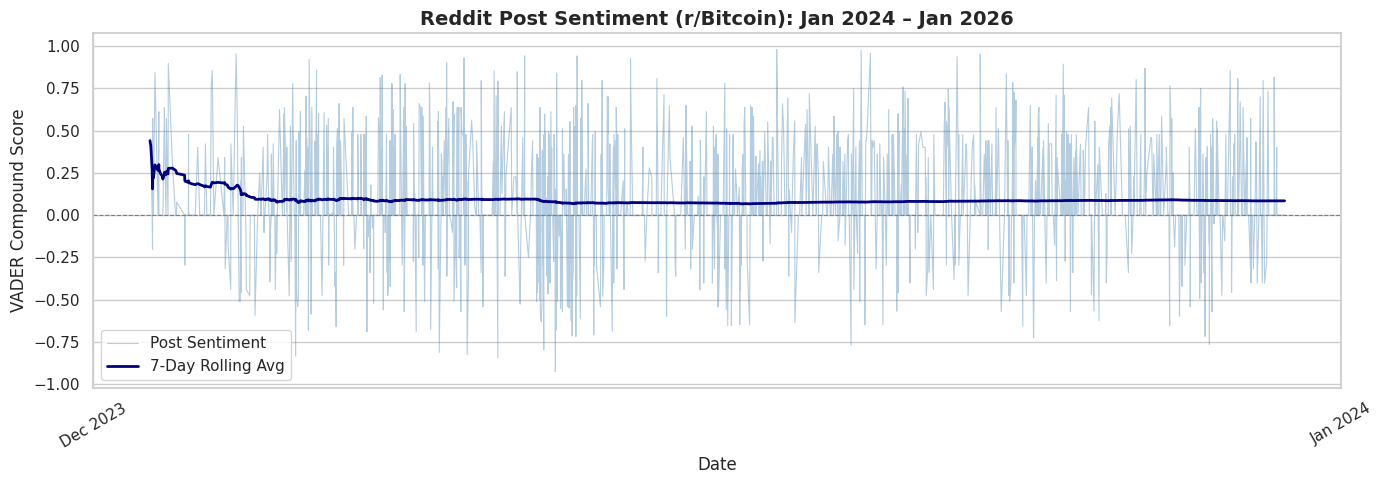

In [196]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_bitcoin_clean['timestamp'], df_bitcoin_clean['sentiment'],
        color='steelblue', linewidth=0.8, alpha=0.4, label='Post Sentiment')
rolling = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax.plot(rolling.index, rolling.values, color='navy', linewidth=2, label='7-Day Rolling Avg')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Reddit Post Sentiment (r/Bitcoin): Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VADER Compound Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig2_sentiment_over_time.png', dpi=150)
plt.show()

In [198]:
print(df_bitcoin_clean['date'].min())
print(df_bitcoin_clean['date'].max())
print(df_bitcoin_clean['date'].nunique())

2024-01-01 00:00:00
2024-01-08 00:00:00
8


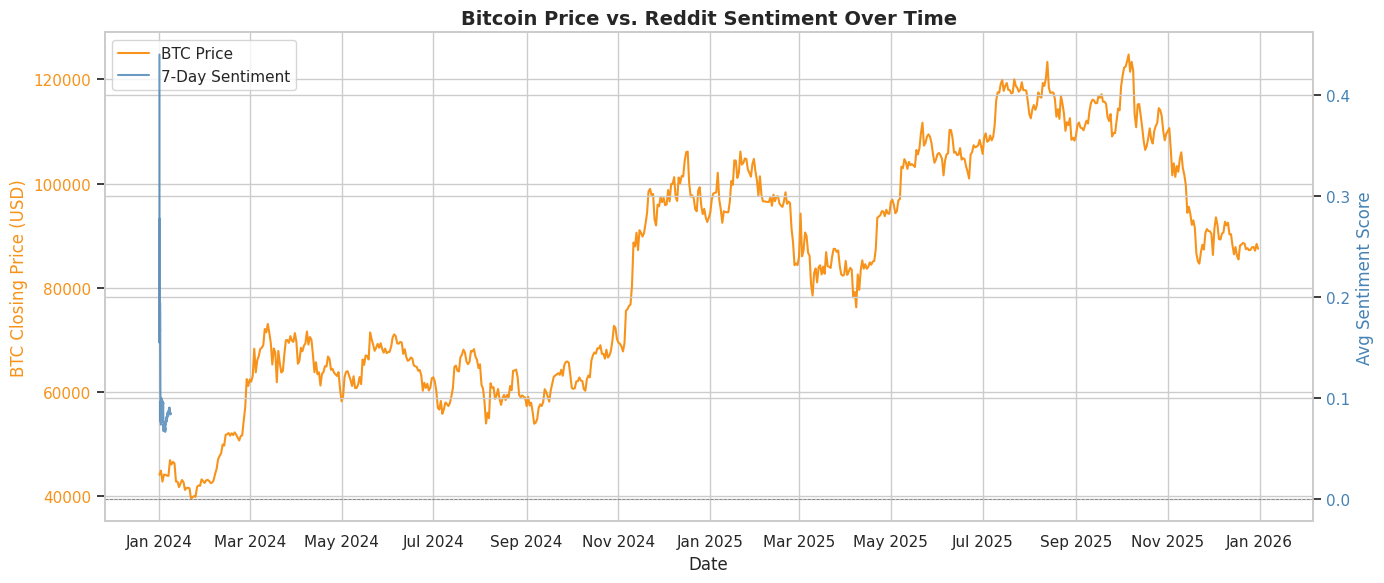

In [197]:
df_bitcoin_clean['date'] = pd.to_datetime(df_bitcoin_clean['timestamp']).dt.normalize()
df_post_merged = pd.merge(df_bitcoin_clean[['date', 'sentiment']], df_price_clean[['date', 'close']], on='date', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5, label='BTC Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Closing Price (USD)', color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')

ax2 = ax1.twinx()
rolling_s = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax2.plot(rolling_s.index, rolling_s.values, color='steelblue', linewidth=1.5, alpha=0.8, label='7-Day Sentiment')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax2.set_ylabel('Avg Sentiment Score', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Bitcoin Price vs. Reddit Sentiment Over Time', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig3_price_vs_sentiment.png', dpi=150)
plt.show()

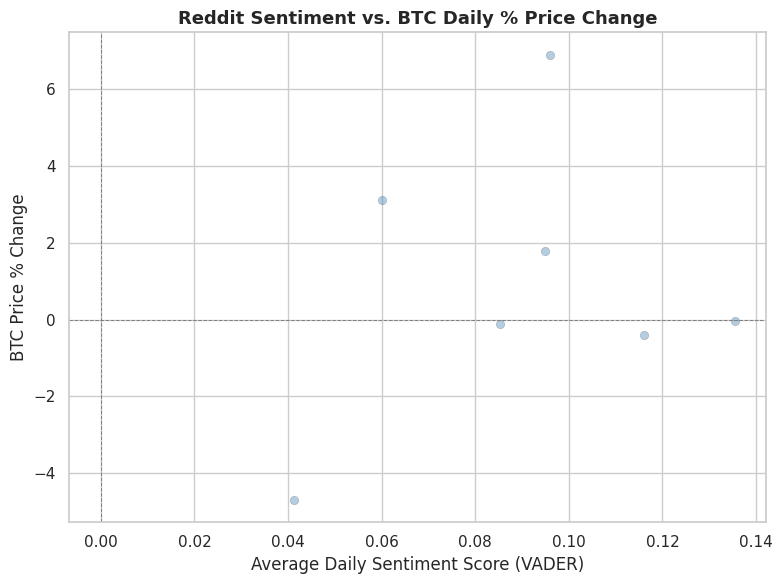

In [185]:
import numpy as np

subset = df_merged[['avg_sentiment', 'price_pct_change']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset['avg_sentiment'], subset['price_pct_change'],
           alpha=0.4, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_title('Reddit Sentiment vs. BTC Daily % Price Change', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (VADER)')
ax.set_ylabel('BTC Price % Change')
plt.tight_layout()
plt.savefig('fig4_scatter_sentiment_vs_price.png', dpi=150)
plt.show()

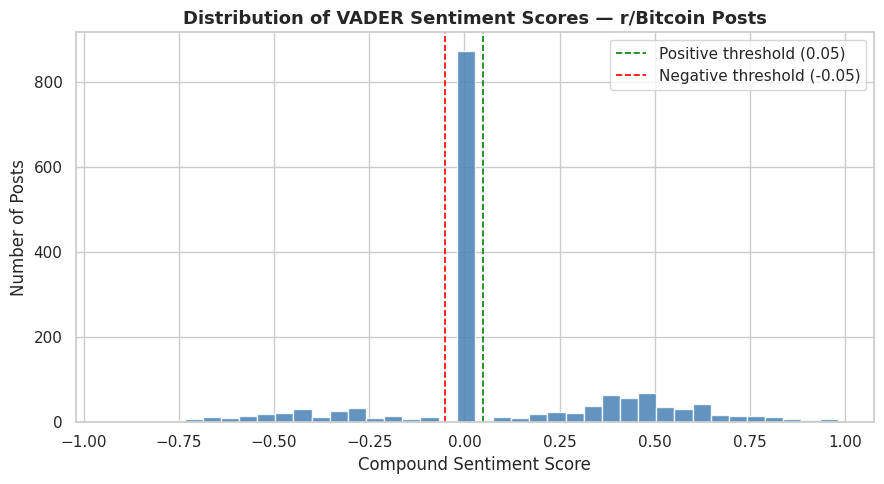

Positive: 508 posts (31.2%)
Neutral: 873 posts (53.7%)
Negative: 245 posts (15.1%)


In [186]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_bitcoin_clean['sentiment'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.05, color='green', linestyle='--', linewidth=1.2, label='Positive threshold (0.05)')
ax.axvline(-0.05, color='red', linestyle='--', linewidth=1.2, label='Negative threshold (-0.05)')
ax.set_title('Distribution of VADER Sentiment Scores — r/Bitcoin Posts', fontsize=13, fontweight='bold')
ax.set_xlabel('Compound Sentiment Score')
ax.set_ylabel('Number of Posts')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_sentiment_distribution.png', dpi=150)
plt.show()

counts = df_bitcoin_clean['sentiment_label'].value_counts()
total = len(df_bitcoin_clean)
for label in ['positive', 'neutral', 'negative']:
    n = counts.get(label, 0)
    print(f'{label.capitalize()}: {n} posts ({n/total*100:.1f}%)')

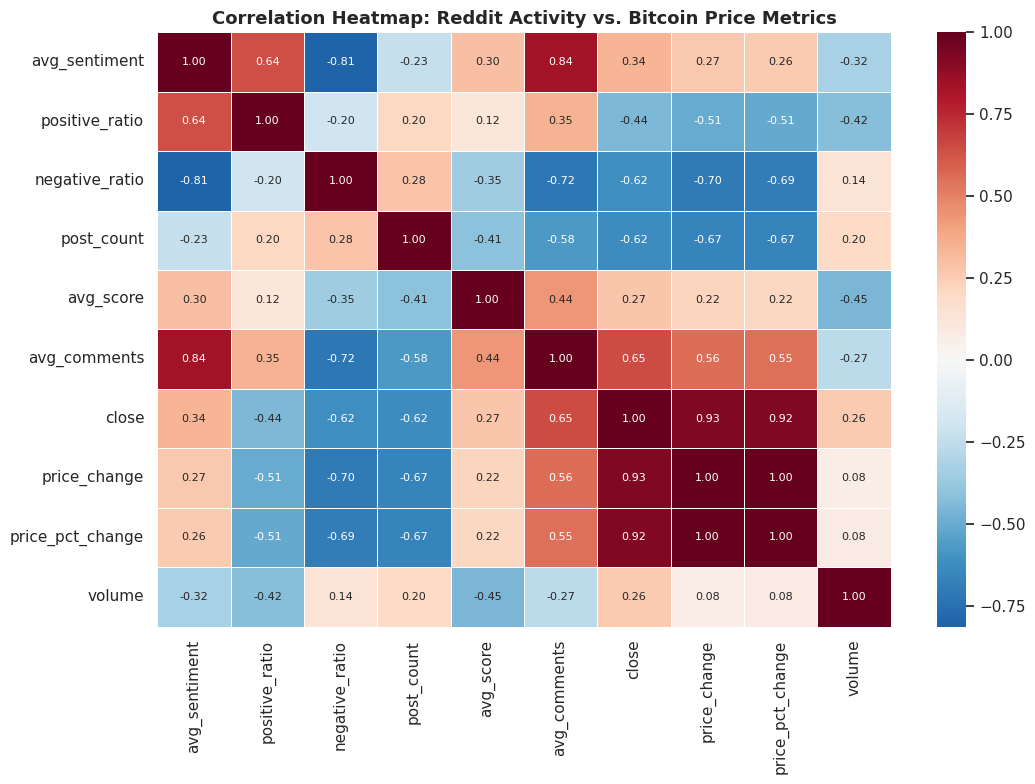

In [187]:
heatmap_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count',
                'avg_score', 'avg_comments', 'close', 'price_change', 'price_pct_change', 'volume']
corr_matrix = df_merged[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap: Reddit Activity vs. Bitcoin Price Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', dpi=150)
plt.show()

/tmp/ipykernel_9651/590628670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_post_price, x='sentiment_label', y='price_pct_change',


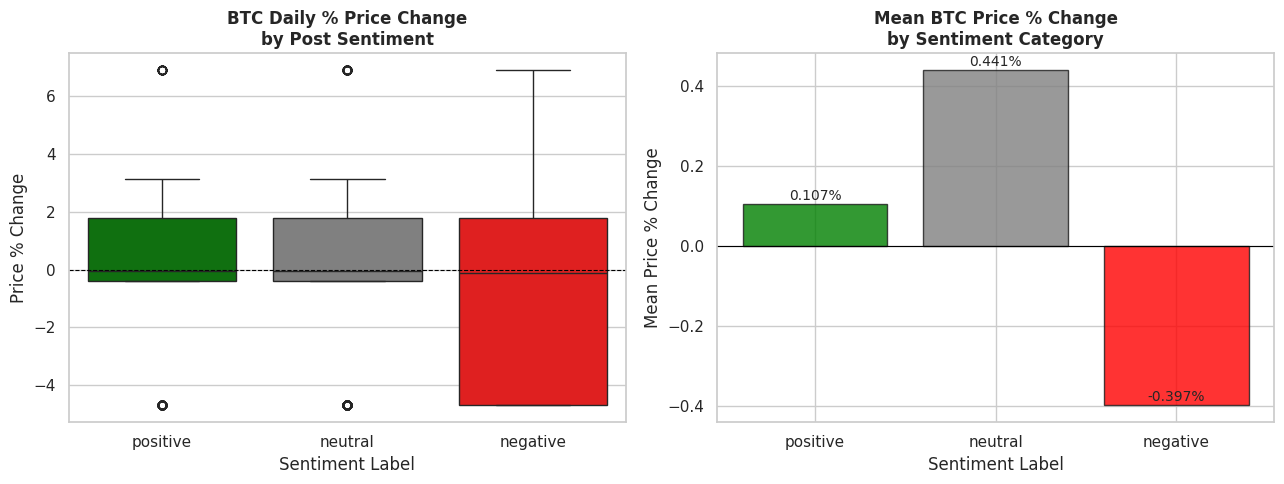

In [188]:
df_post_price = pd.merge(
    df_bitcoin_clean[['date', 'sentiment_label']],
    df_price_clean[['date', 'close', 'price_pct_change']],
    on='date', how='inner'
)

order = ['positive', 'neutral', 'negative']
palette = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_post_price, x='sentiment_label', y='price_pct_change',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('BTC Daily % Price Change\nby Post Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Price % Change')
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)

means = df_post_price.groupby('sentiment_label')['price_pct_change'].mean().reindex(order)
bars = axes[1].bar(means.index, means.values,
                   color=[palette[k] for k in means.index], alpha=0.8, edgecolor='k')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean BTC Price % Change\nby Sentiment Category', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Mean Price % Change')
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig8_price_by_sentiment_category.png', dpi=150)
plt.show()

In [189]:
import pkg_resources

subset = df_merged[['avg_sentiment', 'price_pct_change']].dropna()
if len(subset) >= 2:
    r_same, p_same = stats.pearsonr(subset['avg_sentiment'], subset['price_pct_change'])
else:
    r_same, p_same = float('nan'), float('nan')

vc = df_bitcoin_clean['sentiment_label'].value_counts(normalize=True) * 100
means = df_post_price.groupby('sentiment_label')['price_pct_change'].mean()

print('==================== FINDINGS SUMMARY ====================')
print(f'\n1. Same-day correlation (avg_sentiment vs. price_pct_change):')
print(f'   Pearson r = {r_same:.4f}, p = {p_same:.4f}')
print(f'   => {"Statistically significant" if p_same < 0.05 else "Not statistically significant"}')

print(f'\n2. Sentiment distribution across all posts:')
for label in ['positive', 'neutral', 'negative']:
    print(f'   {label.capitalize()}: {vc.get(label, 0):.1f}%')

print(f'\n3. Mean BTC % price change by sentiment type:')
for label in ['positive', 'neutral', 'negative']:
    print(f'   {label.capitalize()} posts: {means.get(label, float("nan")):.3f}%')

print('\n===========================================================')

print('\nPackage versions:')
packages = ['requests', 'pandas', 'numpy', 'yfinance', 'matplotlib', 'seaborn', 'scipy', 'vaderSentiment']
for pkg in packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f'  {pkg}=={version}')
    except Exception:
        print(f'  {pkg}==unknown')

==================== FINDINGS SUMMARY ====================

1. Same-day correlation (avg_sentiment vs. price_pct_change):
   Pearson r = 0.2570, p = 0.5780
   => Not statistically significant

2. Sentiment distribution across all posts:
   Positive: 31.2%
   Neutral: 53.7%
   Negative: 15.1%

3. Mean BTC % price change by sentiment type:
   Positive posts: 0.107%
   Neutral posts: 0.441%
   Negative posts: -0.397%


Package versions:
  requests==2.32.4
  pandas==2.2.2
  numpy==2.0.2
  yfinance==0.2.66
  matplotlib==3.10.0
  seaborn==0.13.2
  scipy==1.16.3
  vaderSentiment==3.3.2
